<a href="https://colab.research.google.com/github/Likhitha-v-Data-Analyst/ai-writing-detection-project/blob/main/AI_Assisted_Writing_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI-Assisted Writing Detection

In [ ]:
# STEP 1 - importing libraries
import numpy as np
import pandas as pd

In [ ]:
# STEP 2 - configurational library
import warnings
warnings.filterwarnings("ignore")

LOAD THE DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()  # select ai_writing_detection_dataset.csv

Saving ai_writing_detection_dataset.csv to ai_writing_detection_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv('ai_writing_detection_dataset.csv')
df

,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,16959e76,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,Arial,18,0
1,0a304e7f,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0
2,6e629f9f,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,Arial,17,1
3,16334d32,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,24.0,41.92,3.06,5.0,0.05,1.68,Times New Roman,5,0
4,54d8e254,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,2.0,0.00,2.78,1.0,0.09,2.90,Helvetica,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,789f9003,Research_Paper,Undergraduate,Non_Native,1216,10.30,6,0.48,0.21,8.07,121.03,28.0,45.40,2.65,20.0,0.05,1.64,Arial,18,0
10196,d74b373f,Essay,Postgraduate,Native,1062,10.60,6,0.41,0.32,15.08,142.36,25.0,37.91,NaN,4.0,0.06,1.66,Arial,15,0
10197,309522b4,Essay,High_School,Non_Native,950,18.67,5,0.63,0.24,12.60,180.62,23.0,53.38,9.64,8.0,0.00,1.98,Helvetica,20,0
10198,01b91f92,Literature_Review,Undergraduate,Native,1012,20.73,6,0.52,0.05,10.16,146.61,28.0,69.99,NaN,28.0,0.06,1.10,Times New Roman,23,0


In [ ]:
df.columns

Index(['Student_ID', 'Submission_Type', 'Academic_Level', 'Primary_Language',
       'Word_Count', 'Average_Sentence_Length', 'Grammar_Errors',
       'Vocabulary_Richness', 'Passive_Voice_Ratio', 'Reading_Level',
       'Editing_Time', 'Revision_Count', 'Typing_Speed', 'Plagiarism_Score',
       'Citation_Count', 'Punctuation_Density', 'Sentence_Complexity',
       'Font_Family', 'Submission_Hour', 'Is_AI_Assisted'],
      dtype='object')

In [ ]:
df.info()
df.size
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10200 non-null  object 
 1   Submission_Type          10200 non-null  object 
 2   Academic_Level           10200 non-null  object 
 3   Primary_Language         10200 non-null  object 
 4   Word_Count               10200 non-null  int64  
 5   Average_Sentence_Length  10200 non-null  float64
 6   Grammar_Errors           10200 non-null  int64  
 7   Vocabulary_Richness      10200 non-null  float64
 8   Passive_Voice_Ratio      10200 non-null  float64
 9   Reading_Level            10200 non-null  float64
 10  Editing_Time             9311 non-null   float64
 11  Revision_Count           8687 non-null   float64
 12  Typing_Speed             9197 non-null   float64
 13  Plagiarism_Score         9387 non-null   float64
 14  Citation_Count        

(10200, 20)

In [ ]:
# check for the duplicates
df.duplicated().sum()

np.int64(200)

In [ ]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# checking null
df.isnull().sum()

,0
Student_ID,0
Submission_Type,0
Academic_Level,0
Primary_Language,0
Word_Count,0
Average_Sentence_Length,0
Grammar_Errors,0
Vocabulary_Richness,0
Passive_Voice_Ratio,0
Reading_Level,0


FILL NULL WITH MEDIAN

In [ ]:
for col in ['Editing_Time', 'Revision_Count', 'Typing_Speed', 'Plagiarism_Score', 'Citation_Count']:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Submission_Type,0
Academic_Level,0
Primary_Language,0
Word_Count,0
Average_Sentence_Length,0
Grammar_Errors,0
Vocabulary_Richness,0
Passive_Voice_Ratio,0
Reading_Level,0


OUTLEIR DETECTION

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

numeric_cols = ['Word_Count', 'Average_Sentence_Length', 'Grammar_Errors',
                 'Vocabulary_Richness', 'Passive_Voice_Ratio', 'Reading_Level',
                 'Editing_Time', 'Revision_Count', 'Typing_Speed',
                 'Plagiarism_Score', 'Citation_Count', 'Punctuation_Density',
                 'Sentence_Complexity']

for col in numeric_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers | valid range: [{lower:.2f}, {upper:.2f}]")

Word_Count: 23 outliers | valid range: [107.50, 2287.50]
Average_Sentence_Length: 5 outliers | valid range: [3.09, 31.14]
Grammar_Errors: 126 outliers | valid range: [-1.00, 15.00]
Vocabulary_Richness: 5 outliers | valid range: [0.33, 0.92]
Passive_Voice_Ratio: 12 outliers | valid range: [-0.05, 0.47]
Reading_Level: 9 outliers | valid range: [4.12, 19.00]
Editing_Time: 74 outliers | valid range: [-14.96, 343.52]
Revision_Count: 1316 outliers | valid range: [9.50, 37.50]
Typing_Speed: 1351 outliers | valid range: [4.30, 89.31]
Plagiarism_Score: 635 outliers | valid range: [-8.70, 19.94]
Citation_Count: 0 outliers | valid range: [-18.00, 38.00]
Punctuation_Density: 5 outliers | valid range: [-0.01, 0.12]
Sentence_Complexity: 10 outliers | valid range: [0.16, 3.68]


In [ ]:
df.groupby('Is_AI_Assisted')[['Revision_Count', 'Typing_Speed', 'Plagiarism_Score']].describe()

Revision_Count                                              \
                        count       mean       std  min   25%   50%   75%   
Is_AI_Assisted                                                              
0                      8552.0  24.802736  4.585321  7.0  22.0  24.0  27.0   
1                      1448.0   4.983425  7.636688  0.0   1.0   2.0   4.0   

                     Typing_Speed              ...                      \
                 max        count        mean  ...        75%      max   
Is_AI_Assisted                                 ...                       
0               45.0       8552.0   45.129395  ...    54.0225   103.17   
1               24.0       1448.0  784.134655  ...  1200.0000  1200.00   

               Plagiarism_Score                                                \
                          count      mean       std  min     25%   50%    75%   
Is_AI_Assisted                                                                  
0                        8552.0  7.646764  7.675877  0.0  2.5275  4.75  10.36   
1                        1448.0  2.927514  2.965177  0.0  0.8500  2.08   4.61   

                       
                  max  
Is_AI_Assisted         
0               72.33  
1               32.82  

[2 rows x 24 columns]

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

safe_cols = ['Word_Count', 'Average_Sentence_Length', 'Grammar_Errors',
             'Vocabulary_Richness', 'Passive_Voice_Ratio', 'Reading_Level',
             'Editing_Time', 'Citation_Count', 'Punctuation_Density',
             'Sentence_Complexity']

for col in safe_cols:
    df = cap_outliers_iqr(df, col)

In [ ]:
df.describe()

,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Submission_Hour,Is_AI_Assisted
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1200.761550,16.926111,7.109600,0.622318,0.204635,11.477787,158.301013,21.932900,152.137357,6.963417,8.989600,0.053973,1.931622,11.558300,0.144800
std,394.328819,4.637342,3.528149,0.098744,0.096680,2.536904,77.701374,8.664127,338.103770,7.376810,8.740213,0.021649,0.574944,6.940923,0.351917
min,300.000000,5.000000,0.000000,0.325000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,925.000000,13.610000,5.000000,0.550000,0.140000,9.700000,119.472500,20.000000,36.180000,2.040000,3.000000,0.040000,1.480000,5.000000,0.000000
50%,1196.000000,17.070000,7.000000,0.620000,0.200000,11.570000,167.880000,24.000000,46.470000,4.640000,5.000000,0.050000,1.930000,12.000000,0.000000
75%,1470.000000,20.622500,9.000000,0.700000,0.270000,13.420000,209.092500,27.000000,57.432500,9.200000,17.000000,0.070000,2.360000,18.000000,0.000000
max,2287.500000,31.141250,15.000000,0.900000,0.465000,19.000000,343.522500,45.000000,1200.000000,72.330000,36.000000,0.115000,3.680000,23.000000,1.000000


1. Correlation matrix (numeric columns vs Is_AI_Assisted)

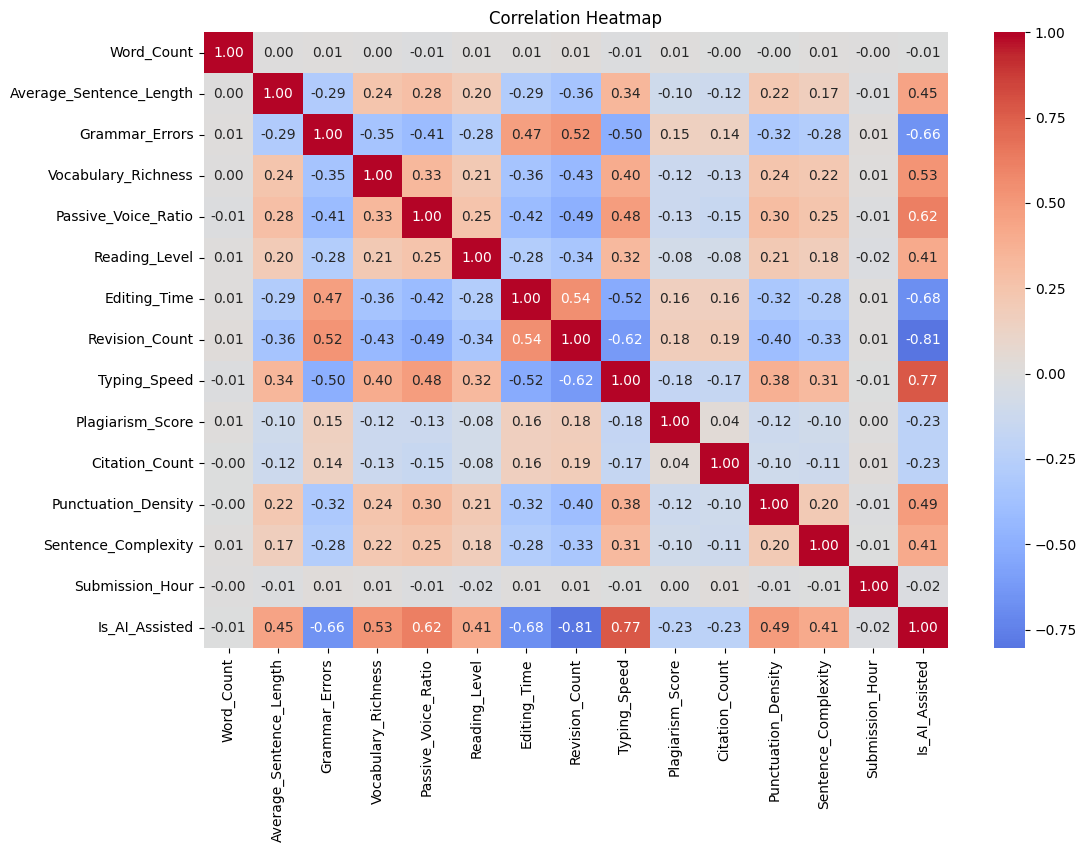

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Word_Count', 'Average_Sentence_Length', 'Grammar_Errors',
                 'Vocabulary_Richness', 'Passive_Voice_Ratio', 'Reading_Level',
                 'Editing_Time', 'Revision_Count', 'Typing_Speed',
                 'Plagiarism_Score', 'Citation_Count', 'Punctuation_Density',
                 'Sentence_Complexity', 'Submission_Hour', 'Is_AI_Assisted']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

2. Boxplots — AI-assisted vs not, for the 3 key features

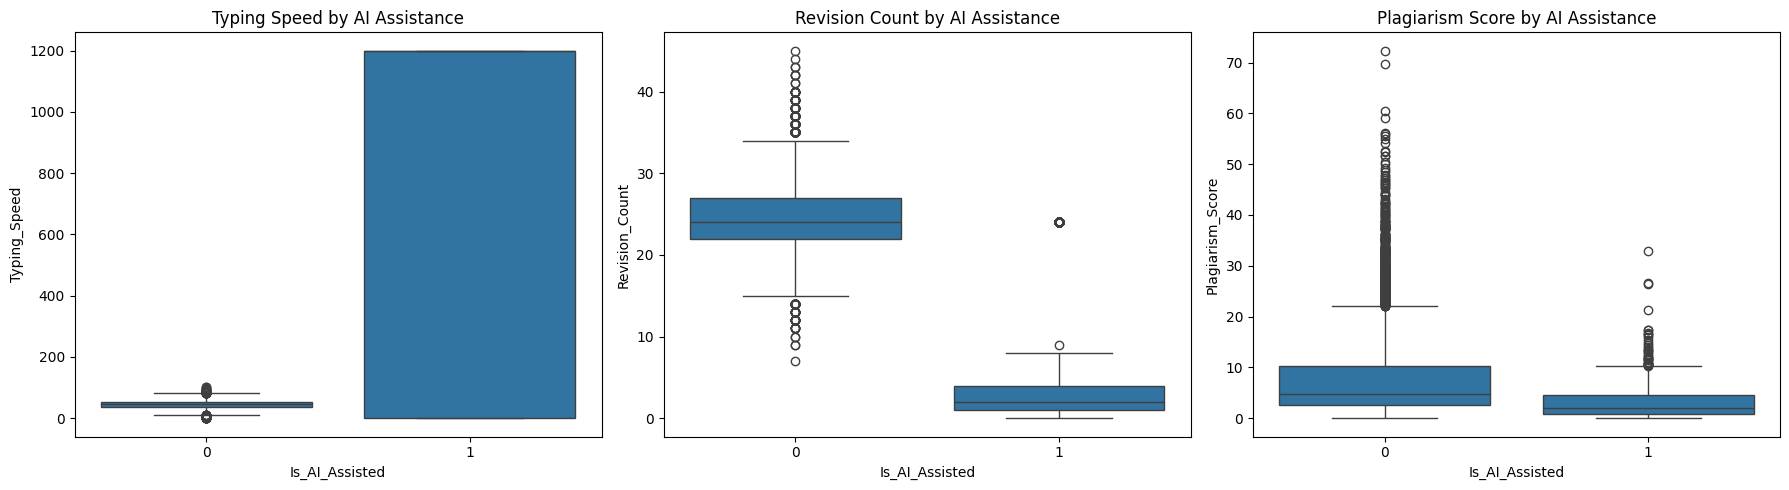

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Is_AI_Assisted', y='Typing_Speed', ax=axes[0])
axes[0].set_title('Typing Speed by AI Assistance')

sns.boxplot(data=df, x='Is_AI_Assisted', y='Revision_Count', ax=axes[1])
axes[1].set_title('Revision Count by AI Assistance')

sns.boxplot(data=df, x='Is_AI_Assisted', y='Plagiarism_Score', ax=axes[2])
axes[2].set_title('Plagiarism Score by AI Assistance')

plt.tight_layout()
plt.show()

3. Distribution of the target class

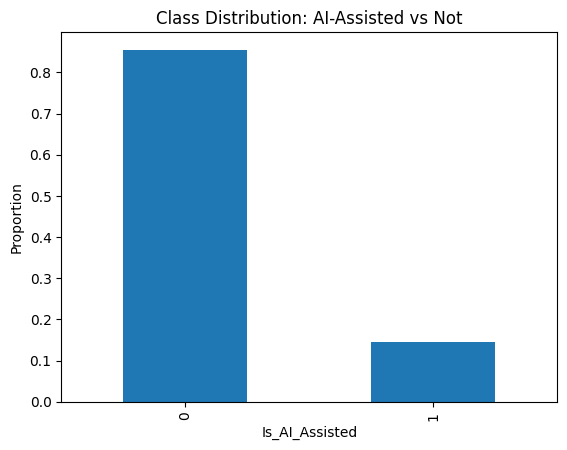

In [ ]:
df['Is_AI_Assisted'].value_counts(normalize=True).plot(kind='bar')
plt.title('Class Distribution: AI-Assisted vs Not')
plt.xlabel('Is_AI_Assisted')
plt.ylabel('Proportion')
plt.show()

4. Categorical breakdown

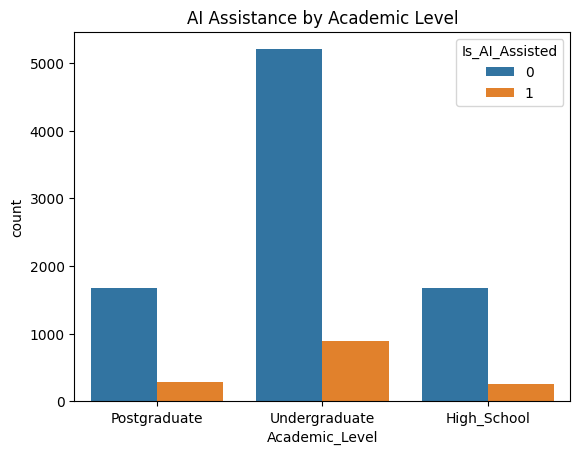

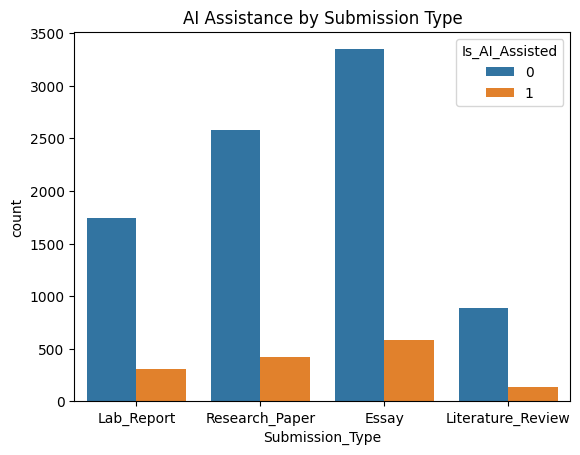

In [ ]:
sns.countplot(data=df, x='Academic_Level', hue='Is_AI_Assisted')
plt.title('AI Assistance by Academic Level')
plt.show()

sns.countplot(data=df, x='Submission_Type', hue='Is_AI_Assisted')
plt.title('AI Assistance by Submission Type')
plt.show()

In [ ]:
df.to_csv('cleaned_ai_writing_dataset.csv', index=False)

In [ ]:
from google.colab import files
files.download('cleaned_ai_writing_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>